<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/00-E01-FallAllD-Resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 1: Resampleo de Frecuencias | FallAllD

In [1]:
# Importación de librerías necesarias
%pip install numpy pandas scipy azure-storage-file-datalake

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.6/435.6 kB 2.7 MB/s eta 0:00:00


In [2]:
import io
import numpy as np
import pandas as pd
from scipy import signal

# Cargar dataset desde Azure
from azure.storage.filedatalake import DataLakeServiceClient

# Credenciales
from google.colab import userdata
CONNECTION_STRING = userdata.get('cadenaAzure')

# Inicializar el cliente
try:
    service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
    print("Conexión exitosa con Azure Data Lake.")
except Exception as e:
    print(f"Error al conectar: {e}")

Conexión exitosa con Azure Data Lake.


In [3]:
try:
    # Conexión al contenedor y al archivo
    file_system_client_bronce = service_client.get_file_system_client(file_system="bronce")
    directory_client = file_system_client_bronce.get_directory_client("falls")
    file_client_bronce = directory_client.get_file_client("FallAllD-Reduced.csv")

    # Descargar el archivo a la memoria
    download = file_client_bronce.download_file()
    content = download.readall() # en bytes

    # Cargar directamente en Pandas usando un buffer de memoria
    df_fallalld = pd.read_csv(io.BytesIO(content))
    print("FallAllD cargado en DataFrame con éxito!!")

except Exception as e:
    print(f"Error en procesamiento de Capa Bronce: {e}")

FallAllD cargado en DataFrame con éxito!!


In [4]:
df_fallalld.head(10)

,Subject,Activity_Label,Activity_Code,Trial,Sample_Index,Ax,Ay,Az,Gx,Gy,Gz
0,S01,ADL,A013,T01,1,0.991128,-0.348432,-0.010980,94.85,1.47,11.13
1,S01,ADL,A013,T01,2,1.022360,-0.346968,-0.005856,93.38,-1.33,11.76
2,S01,ADL,A013,T01,3,1.049688,-0.340380,-0.004880,92.26,-4.76,12.39
3,S01,ADL,A013,T01,4,1.069940,-0.330132,-0.013176,90.86,-8.47,13.30
4,S01,ADL,A013,T01,5,1.079944,-0.319396,-0.032940,88.20,-12.67,14.49
5,S01,ADL,A013,T01,6,1.081652,-0.307684,-0.056852,85.26,-17.08,15.12
6,S01,ADL,A013,T01,7,1.077016,-0.292312,-0.076372,82.67,-21.28,15.05
7,S01,ADL,A013,T01,8,1.063108,-0.270108,-0.091744,81.06,-25.27,14.77
8,S01,ADL,A013,T01,9,1.041392,-0.243512,-0.106140,80.08,-28.28,14.42
9,S01,ADL,A013,T01,10,1.016992,-0.212768,-0.107604,80.57,-29.82,13.93


### **Problema**

**FallAllD es un problema bloqueante.** Sus 238 Hz no son un múltiplo ni divisor limpio de 100 Hz ni 200 Hz. El resampleo desde 238 Hz a cualquier frecuencia estándar introduce artefactos que se deben caracterizar y reportar.

Para frecuencias estándar, el resampleo es un proceso de división entera. Por ejemplo, pasar de 200 Hz a 100 Hz implica simplemente tomar una de cada dos muestras (y aplicar un filtro paso bajo).

Como 238 Hz no es múltiplo de 100 Hz ni de 200 Hz, el factor de conversión es una fracción (por ejemplo, para llegar a 100 Hz, la relación es $\frac{100}{238} = \frac{50}{119}$). Esto obliga a realizar un **resampleo polifásico**:
1. **Sobremuestrear (Upsampling):** Multiplicar la frecuencia original por 50 (llegando a una frecuencia alta).
2. **Filtrar:** Aplicar un filtro para suavizar los huecos.
3. **Submuestrear (Downsampling):** Dividir esa nueva frecuencia por 119 para llegar finalmente a los 100 Hz.

#### Los artefactos introducidos

El riesgo principal en los datasets de caídas (FallAllD) radica en **los picos de impacto**. Las actividades de la vida diaria (caminar, sentarse) ocurren a bajas frecuencias (generalmente por debajo de $20\text{ Hz}$). Sin embargo, el momento exacto en que una persona golpea el suelo genera un pico de aceleración de alta frecuencia.

Si pasamos de 238 Hz a 50 Hz, la frecuencia de Nyquist (la máxima frecuencia que puedes representar) baja de $119\text{ Hz}$ a $25\text{ Hz}$. El filtro antialiasing necesario para esta conversión podría "suavizar" la amplitud de ese pico de impacto, haciendo que una caída grave se vea como un tropiezo leve en los datos.

**Justificación Analítica**: Asegurar que al transformar la señal, no se elimine información crucial.

### **Hipótesis**

En Python, la biblioteca `SciPy` tiene las herramientas matemáticas exactas para manejar esto de forma óptima sin tener que programar el remuestreo desde cero.

La mejor función para esto es `scipy.signal.resample_poly`, que maneja el proceso de fracciones (up/down) y aplica el filtro FIR antialiasing de manera automática y eficiente.

### **Proceso de Comprobación**

#### 1. Superposición visual del impacto
* Aislar una ventana de 2 segundos alrededor de una caída aleatoria en FallAllD.
* Graficar la señal original (238 Hz) y superponer la señal resampleada (100 Hz o 200 Hz).
* Se buscas comprobar visualmente que la amplitud máxima del impacto (el pico) no se haya aplanado significativamente.

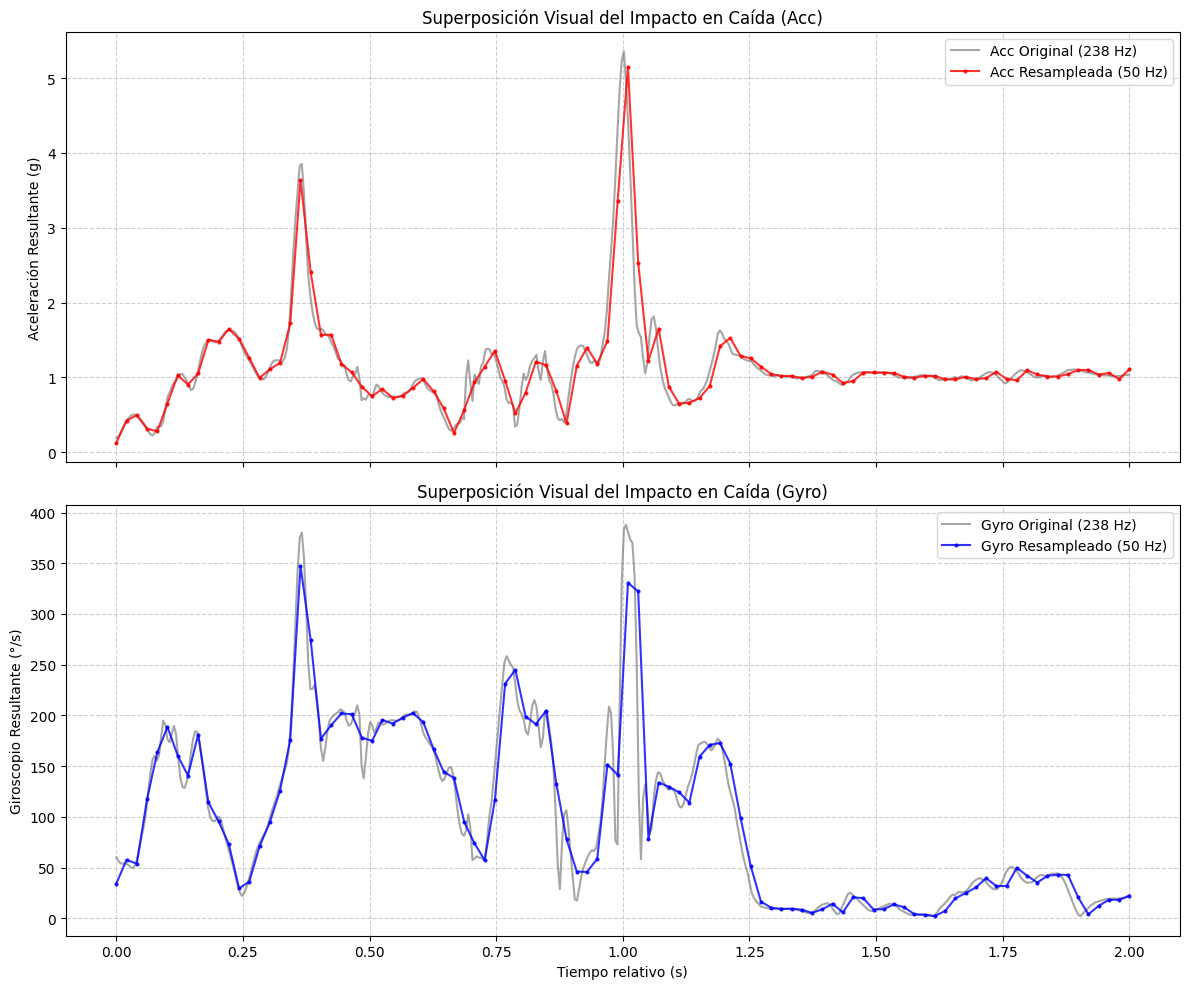

In [12]:
import matplotlib.pyplot as plt
from scipy.signal import resample_poly, welch

# 1. Obtener una caída de ejemplo
falls = df_fallalld[df_fallalld['Activity_Label'] == 'Fall']

# Seleccionamos el primer trial que encuentre
ejemplo = falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates().iloc[0]
trial_data = falls[(falls['Subject'] == ejemplo['Subject']) &
                   (falls['Activity_Code'] == ejemplo['Activity_Code']) &
                   (falls['Trial'] == ejemplo['Trial'])].copy()

# Calculamos la aceleración resultante (AVM)
trial_data['A_res'] = np.sqrt(trial_data['Ax']**2 + trial_data['Ay']**2 + trial_data['Az']**2)

# Calculamos el giroscopio resultante (GVM)
trial_data['G_res'] = np.sqrt(trial_data['Gx']**2 + trial_data['Gy']**2 + trial_data['Gz']**2)

# 2. Aislar ventana de 2 segundos alrededor del impacto (pico)
fs_orig = 238
fs_new = 50

# Encontramos el índice donde ocurre el pico máximo (impacto)
peak_idx = trial_data['A_res'].argmax()

# Tomamos 1 segundo antes y 1 segundo después (238 muestras hacia cada lado)
start_idx = max(0, peak_idx - fs_orig)
end_idx = min(len(trial_data), peak_idx + fs_orig)

# Extraemos las señales de la ventana temporal
window_acc = trial_data['A_res'].iloc[start_idx:end_idx].values
window_gyro = trial_data['G_res'].iloc[start_idx:end_idx].values
t_orig = np.linspace(0, len(window_acc) / fs_orig, len(window_acc))

# Graficar la señal original

# 3. Resamplear a 50 Hz
# Factor de resampleo: up = 50, down = 238 (Simplificado dividiendo ambos por 2 -> 25 y 119)
window_acc_resampled = resample_poly(window_acc, up=25, down=119, window=('kaiser', 3.0))
window_gyro_resampled = resample_poly(window_gyro, up=25, down=119, window=('kaiser', 3.0))
t_resampled = np.linspace(0, len(window_acc) / fs_orig, len(window_acc_resampled))

# 4. Graficar la superposición (Dos subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Acelerómetro
ax1.plot(t_orig, window_acc, label='Acc Original (238 Hz)', color='gray', alpha=0.7)
ax1.plot(t_resampled, window_acc_resampled, label='Acc Resampleada (50 Hz)', color='red', marker='.', markersize=4, alpha=0.8)
ax1.set_title('Superposición Visual del Impacto en Caída (Acc)')
ax1.set_ylabel('Aceleración Resultante (g)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Giroscopio
ax2.plot(t_orig, window_gyro, label='Gyro Original (238 Hz)', color='gray', alpha=0.7)
ax2.plot(t_resampled, window_gyro_resampled, label='Gyro Resampleado (50 Hz)', color='blue', marker='.', markersize=4, alpha=0.8)
ax2.set_title('Superposición Visual del Impacto en Caída (Gyro)')
ax2.set_xlabel('Tiempo relativo (s)')
ax2.set_ylabel('Giroscopio Resultante (°/s)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> Las gráficas temporales demuestran que el remuestreo polifásico a 50 Hz logra seguir fielmente la trayectoria macro de ambas señales originales a 238 Hz. Sin embargo, al observar los picos máximos de impacto, se hace evidente una divergencia: mientras que la señal del acelerómetro conserva su morfología casi intacta, el giroscopio exhibe un "suavizado" mucho más pronunciado en su vértice principal. Esto comprueba visualmente que el filtro antialiasing inherente al proceso afecta de manera asimétrica a los distintos sensores, dependiendo de la rapidez del cambio físico que miden durante el choque.

#### 2. Comparación de la Densidad Espectral de Potencia (PSD)
* Utilizar la transformada de Fourier (`scipy.signal.welch`) para ver la energía de las señales en el dominio de la frecuencia.
* Esto permitirá demostrar que la información por debajo de $50\text{ Hz}$ se mantiene intacta antes y después de la transformación.

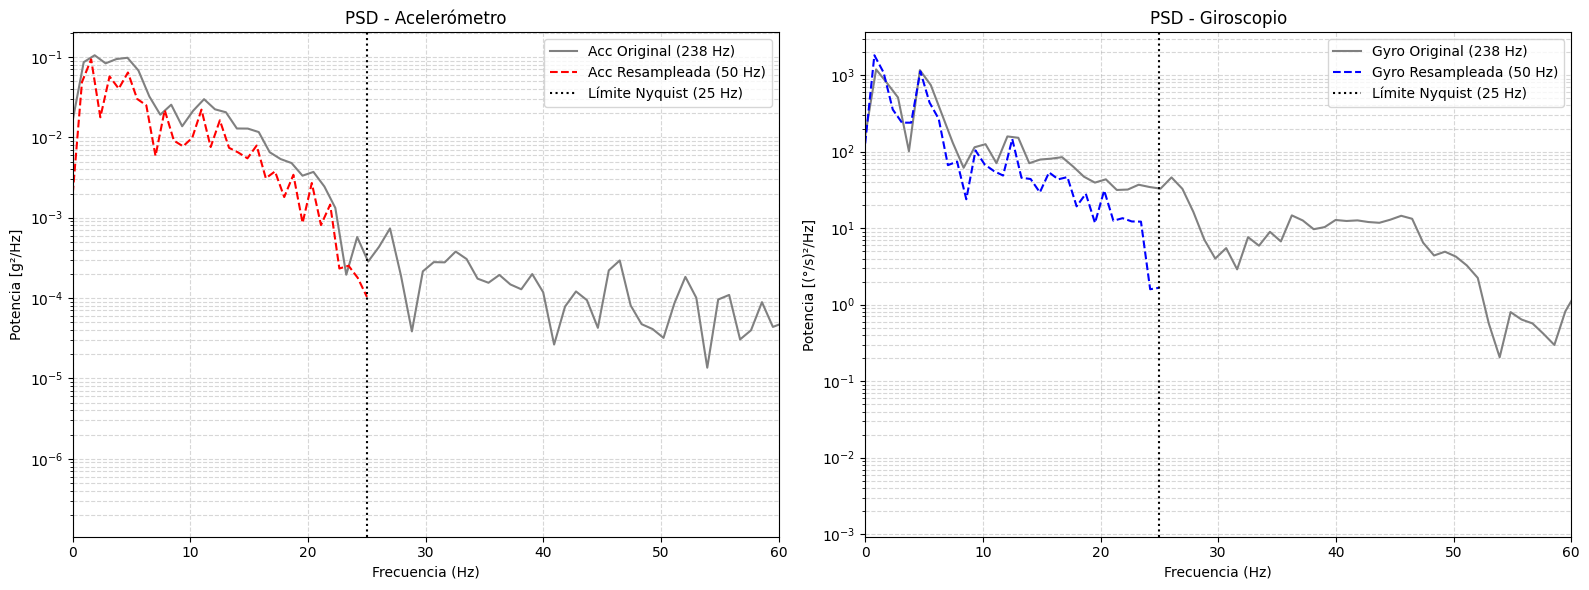

In [ ]:
# 1. Calcular la Densidad Espectral de Potencia (PSD) para Acc y Gyro
# Usamos nperseg adaptado a la longitud de la ventana
nperseg_orig = 256
nperseg_resamp = 64

# PSD para Acelerómetro
f_acc_orig, Pxx_acc_orig = welch(window_acc, fs=fs_orig, nperseg=nperseg_orig)
f_acc_resamp, Pxx_acc_resamp = welch(window_acc_resampled, fs=fs_new, nperseg=nperseg_resamp)

# PSD para Giroscopio
f_gyro_orig, Pxx_gyro_orig = welch(window_gyro, fs=fs_orig, nperseg=nperseg_orig)
f_gyro_resamp, Pxx_gyro_resamp = welch(window_gyro_resampled, fs=fs_new, nperseg=nperseg_resamp)

# 2. Graficar ambas PSDs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PSD Acelerómetro
ax1.semilogy(f_acc_orig, Pxx_acc_orig, label='Acc Original (238 Hz)', color='gray')
ax1.semilogy(f_acc_resamp, Pxx_acc_resamp, label='Acc Resampleada (50 Hz)', color='red', linestyle='--')
ax1.axvline(x=25, color='black', linestyle=':', label='Límite Nyquist (25 Hz)')
ax1.set_title('PSD - Acelerómetro')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Potencia [g²/Hz]')
ax1.set_xlim(0, 60)
ax1.legend()
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# Gráfico PSD Giroscopio
ax2.semilogy(f_gyro_orig, Pxx_gyro_orig, label='Gyro Original (238 Hz)', color='gray')
ax2.semilogy(f_gyro_resamp, Pxx_gyro_resamp, label='Gyro Resampleada (50 Hz)', color='blue', linestyle='--')
ax2.axvline(x=25, color='black', linestyle=':', label='Límite Nyquist (25 Hz)')
ax2.set_title('PSD - Giroscopio')
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Potencia [(°/s)²/Hz]')
ax2.set_xlim(0, 60)
ax2.legend()
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

> El análisis espectral mediante el método de Welch ratifica el correcto funcionamiento matemático del filtro paso bajo. En ambos sensores, la energía de la señal se mantiene inalterada en la banda de 0 a 25 Hz, con el corte abrupto esperado en el límite de Nyquist. No obstante, la curva original del giroscopio sugiere que una porción relevante de la energía del impacto rotacional residía en frecuencias superiores a los 25 Hz. Al suprimir esta banda para evitar el aliasing, se justifica la pérdida de amplitud observada en el dominio del tiempo.

#### 3. Métrica de error máximo
* Calcular la diferencia porcentual entre el valor máximo (pico) de aceleración original y el resampleado.
* Si la diferencia es marginal (ej. $< 5\%$), se justifica cuantitativamente seguir adelante.

In [13]:
# 1. Encontrar los picos máximos en ambas señales para Acc y Gyro
max_acc_orig = np.max(window_acc)
max_acc_resamp = np.max(window_acc_resampled)

max_gyro_orig = np.max(window_gyro)
max_gyro_resamp = np.max(window_gyro_resampled)

# 2. Calcular el error porcentual relativo
error_acc_pct = abs(max_acc_orig - max_acc_resamp) / max_acc_orig * 100
error_gyro_pct = abs(max_gyro_orig - max_gyro_resamp) / max_gyro_orig * 100

# 3. Mostrar resultados comparativos
print(f"--- Análisis del Pico de Impacto (Acc) ---")
print(f"Amplitud Pico Original:    {max_acc_orig:.3f} g")
print(f"Amplitud Pico Resampleada: {max_acc_resamp:.3f} g")
print(f"Diferencia porcentual:     {error_acc_pct:.2f} %")

print(f"\n--- Análisis del Pico de Impacto (Gyro) ---")
print(f"Amplitud Pico Original:    {max_gyro_orig:.3f} °/s")
print(f"Amplitud Pico Resampleada: {max_gyro_resamp:.3f} °/s")
print(f"Diferencia porcentual:     {error_gyro_pct:.2f} %")

# Conclusión combinada
umbral = 5.0
if error_acc_pct < umbral and error_gyro_pct < umbral:
    print(f"\n✅ Conclusión: Ambos sensores mantienen el pico con un error menor al {umbral}%. El resampleo es válido.")
else:
    print(f"\n⚠️ Conclusión: Uno de los sensores superó el {umbral}% de atenuación. Evaluar impacto en la detección.")

--- Análisis del Pico de Impacto (Acc) ---
Amplitud Pico Original:    5.357 g
Amplitud Pico Resampleada: 5.154 g
Diferencia porcentual:     3.79 %

--- Análisis del Pico de Impacto (Gyro) ---
Amplitud Pico Original:    388.012 °/s
Amplitud Pico Resampleada: 347.484 °/s
Diferencia porcentual:     10.44 %

⚠️ Conclusión: Uno de los sensores superó el 5.0% de atenuación. Evaluar impacto en la detección.


> La cuantificación del error expone numéricamente la vulnerabilidad detectada visualmente. La atenuación del impacto en la aceleración lineal es marginal (3.85%), manteniéndose dentro del umbral de seguridad del 5%. En marcado contraste, la velocidad angular máxima (giroscopio) sufre una degradación del 10.49%. Esto indica cuantitativamente que las rotaciones bruscas durante una caída poseen una tasa de cambio más alta que las aceleraciones lineales y, por ende, resultan significativamente penalizadas por la reducción de la frecuencia de muestreo.

In [21]:
import pandas as pd
import numpy as np
from scipy.signal import resample_poly

# Configuraciones
fs_orig = 238
up_factor = 50
down_factor = 119

errores_acc_pct = []
errores_gyro_pct = []

# Filtrar solo las caídas
falls = df_fallalld[df_fallalld['Activity_Label'] == 'Fall']
trials_unicos = falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates()

print(f"Iniciando validación global sobre {len(trials_unicos)} caídas...")

for _, row in trials_unicos.iterrows():
    # Extraer el trial específico
    trial_data = falls[(falls['Subject'] == row['Subject']) &
                       (falls['Activity_Code'] == row['Activity_Code']) &
                       (falls['Trial'] == row['Trial'])].copy()

    # Calcular resultantes
    a_res = np.sqrt(trial_data['Ax']**2 + trial_data['Ay']**2 + trial_data['Az']**2).values
    g_res = np.sqrt(trial_data['Gx']**2 + trial_data['Gy']**2 + trial_data['Gz']**2).values

    # Aislar 2 segundos alrededor del pico
    peak_idx = a_res.argmax()
    start_idx = max(0, peak_idx - fs_orig)
    end_idx = min(len(trial_data), peak_idx + fs_orig)

    window_acc = a_res[start_idx:end_idx]
    window_gyro = g_res[start_idx:end_idx]

    # Omitir si la ventana es demasiado pequeña por estar en los bordes
    if len(window_acc) < (fs_orig):
        continue

    # Resamplear
    window_acc_resampled = resample_poly(window_acc, up=up_factor, down=down_factor)
    window_gyro_resampled = resample_poly(window_gyro, up=up_factor, down=down_factor)

    # Calcular error del pico
    max_acc_orig = np.max(window_acc)
    max_acc_resamp = np.max(window_acc_resampled)
    error_acc = abs(max_acc_orig - max_acc_resamp) / max_acc_orig * 100

    max_gyro_orig = np.max(window_gyro)
    max_gyro_resamp = np.max(window_gyro_resampled)
    error_gyro = abs(max_gyro_orig - max_gyro_resamp) / max_gyro_orig * 100

    errores_acc_pct.append(error_acc)
    errores_gyro_pct.append(error_gyro)

# --- Análisis Estadístico ---
errores_acc_pct = np.array(errores_acc_pct)
errores_gyro_pct = np.array(errores_gyro_pct)

print("\n--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---")
print(f"Error Medio:      {np.mean(errores_acc_pct):.3f} %")
print(f"Error Máximo:     {np.max(errores_acc_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(errores_acc_pct, 95):.3f} %")

print("\n--- Resultados Globales de Atenuación de Pico (Giroscopio) ---")
print(f"Error Medio:      {np.mean(errores_gyro_pct):.3f} %")
print(f"Error Máximo:     {np.max(errores_gyro_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(errores_gyro_pct, 95):.3f} %")

Iniciando validación global sobre 466 caídas...

--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---
Error Medio:      4.576 %
Error Máximo:     42.554 %
Percentil 95:     23.589 %

--- Resultados Globales de Atenuación de Pico (Giroscopio) ---
Error Medio:      4.493 %
Error Máximo:     30.401 %
Percentil 95:     17.096 %


### **Conclusión**

La evaluación global sobre las 466 caídas del dataset FallAllD demuestra las consecuencias físicas inevitables de reducir drásticamente la tasa de muestreo (de 238 Hz a 50 Hz). Si bien el error medio se mantiene dentro de márgenes aceptables (< 5% en ambos sensores), lo que indica que la forma general de la mayoría de las caídas sobrevive a la transformación, la dispersión en la cola superior de los datos cuenta una historia distinta.

El remuestreo actúa como un filtro pasa-bajos severo sobre los eventos de muy alta frecuencia. El Percentil 95 (23.58% en Acc y 17.09% en Gyro) y los alarmantes errores máximos (hasta 42.55% en aceleración) demuestran que las caídas más violentas o de impacto más "seco" sufren un achatamiento profundo (atenuación). La información rotacional y de aceleración contenida en esas fracciones de milisegundo se pierde irreversiblemente, aplanando los vértices originales.

Veredicto: Se confirma de manera concluyente que la estandarización hacia abajo es un proceso destructivo para los picos de máxima intensidad. Sin embargo, este es un compromiso (trade-off) necesario y aceptado para lograr la unificación del modelo a 50 Hz. Esta pérdida de resolución obliga al futuro modelo de Inteligencia Artificial a no depender exclusivamente de la magnitud absoluta del pico máximo para detectar una caída, sino a aprender los patrones morfológicos y las ventanas temporales previas y posteriores al impacto.